In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\Python_ML_projects\Uber_Project\UberDataset.csv")
df

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit
...,...,...,...,...,...,...,...
1151,12/31/2016 13:24,12/31/2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12/31/2016 15:03,12/31/2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12/31/2016 21:32,12/31/2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12/31/2016 22:08,12/31/2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [7]:
df.shape

(1156, 7)

# Data Preprocessing

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [9]:
df.isna().sum()

START_DATE      0
END_DATE        1
CATEGORY        1
START           1
STOP            1
MILES           0
PURPOSE       503
dtype: int64

In [13]:
df["PURPOSE"].fillna("NOT",inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_11224\4109592258.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["PURPOSE"].fillna("NOT",inplace=True)


In [14]:
df.isna().sum()

START_DATE    0
END_DATE      1
CATEGORY      1
START         1
STOP          1
MILES         0
PURPOSE       0
dtype: int64

In [15]:
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NOT
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies


In [18]:
df["START_DATE"] = pd.to_datetime(df["START_DATE"],errors="coerce")
df["END_DATE"] = pd.to_datetime(df["END_DATE"],errors="coerce")

In [19]:
df.dtypes

START_DATE    datetime64[ns]
END_DATE      datetime64[ns]
CATEGORY              object
START                 object
STOP                  object
MILES                float64
PURPOSE               object
dtype: object

In [20]:
from datetime import datetime

df["date"] = pd.DatetimeIndex(df["START_DATE"]).date

In [23]:
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0


In [22]:
df["time"] = pd.DatetimeIndex(df["START_DATE"]).hour

In [25]:
df["day-night"] = pd.cut(x=df["time"],bins=[0,10,15,19,24],labels = ["morning","afternoon","evening","night"])

In [26]:
df.head(3)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1.0,morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,night


In [27]:
df.dropna(inplace=True)

In [28]:
df.isna().sum()

START_DATE    0
END_DATE      0
CATEGORY      0
START         0
STOP          0
MILES         0
PURPOSE       0
date          0
time          0
day-night     0
dtype: int64

In [29]:
df.shape

(413, 10)

# Data Visualization

# 1.In which category do people book the most Uber rides?

In [32]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night


In [33]:
df["CATEGORY"].value_counts()

CATEGORY
Business    400
Personal     13
Name: count, dtype: int64

<Axes: xlabel='CATEGORY', ylabel='count'>

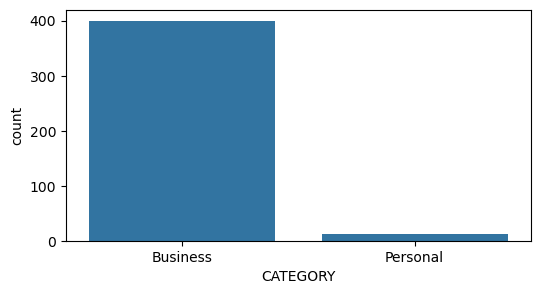

In [36]:
plt.figure(figsize = (6,3))

sns.countplot(data=df, x="CATEGORY")

# 2. For which purpose do people book Uber rides the most?

In [37]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night


In [38]:
df["PURPOSE"].value_counts()

PURPOSE
NOT                159
Meeting             78
Meal/Entertain      62
Customer Visit      46
Errand/Supplies     45
Temporary Site      14
Between Offices      9
Name: count, dtype: int64

<Axes: xlabel='PURPOSE', ylabel='count'>

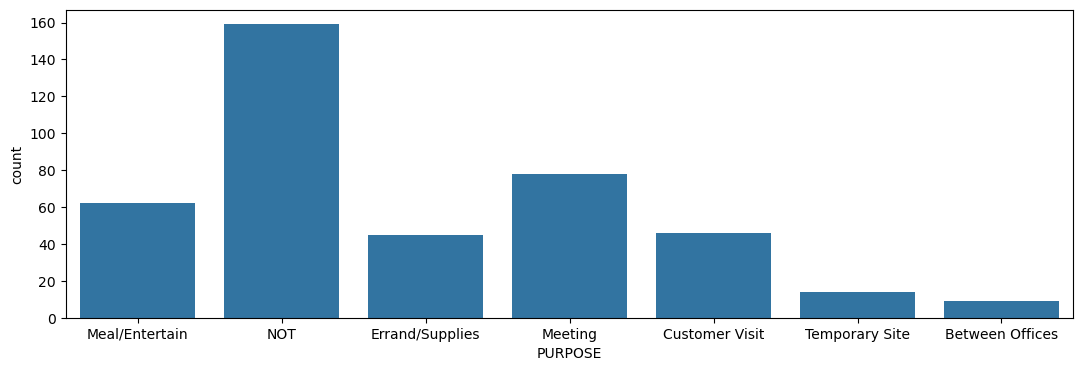

In [44]:
plt.figure(figsize = (13,4))
sns.countplot(data=df, x="PURPOSE")

# 3.At what time do people book cabs the most from Uber?

In [45]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night


In [46]:
df["day-night"].value_counts()

day-night
afternoon    142
evening      137
night         71
morning       63
Name: count, dtype: int64

<Axes: xlabel='day-night', ylabel='count'>

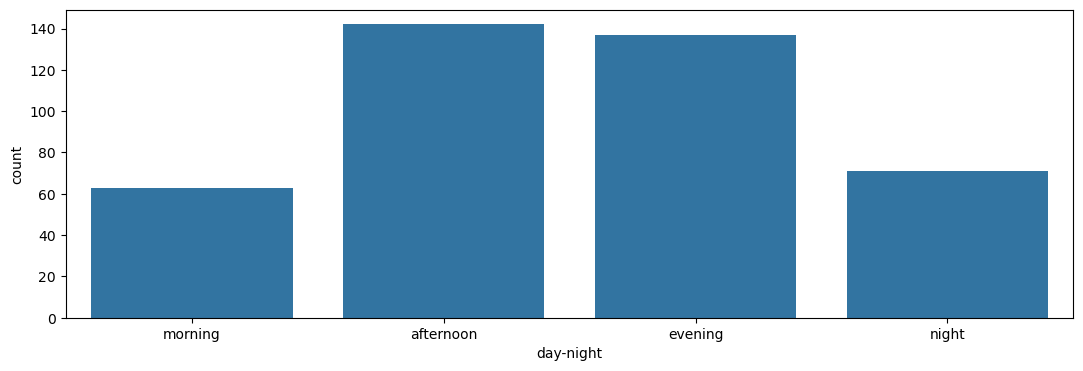

In [47]:
plt.figure(figsize = (13,4))
sns.countplot(data=df, x="day-night")

# 4. In which months do people book Uber rides less frequently?

In [48]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night


In [49]:
df["month"] =pd.to_datetime(df["date"]).dt.month

In [50]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,month
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night,1


In [54]:
df["month"].value_counts()

month
11    63
8     43
3     42
6     42
2     40
12    39
7     34
5     26
4     24
10    24
1     23
9     13
Name: count, dtype: int64

<Axes: xlabel='month', ylabel='count'>

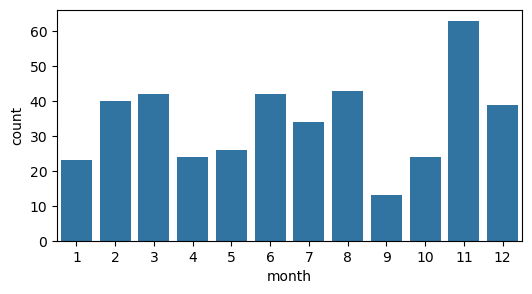

In [55]:
plt.figure(figsize = (6,3))

sns.countplot(data=df, x="month")

# 5.On which days of the week do people book Uber rides the most?

In [56]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,month
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night,1


In [59]:
df["day"] = pd.to_datetime(df["date"]).dt.weekday

In [60]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,month,day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night,1,4


In [61]:
data_label = {0:"mon",1:"tues",2:"wed",3:"thur",4:"fri",5:"sat",6:"sun"}

df["day"] = df["day"].map(data_label)

In [62]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,month,day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night,1,fri


In [65]:
day_label = df["day"].value_counts()

In [66]:
day_label

day
fri     86
thur    61
mon     61
tues    58
sat     52
wed     48
sun     47
Name: count, dtype: int64

<Axes: xlabel='day', ylabel='count'>

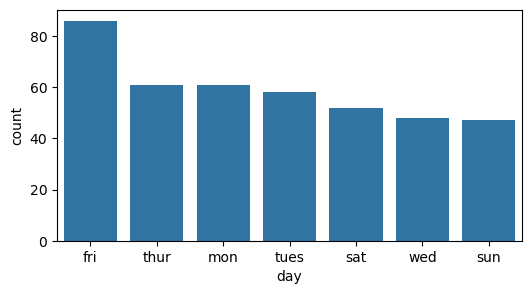

In [67]:
plt.figure(figsize = (6,3))

sns.barplot(x=day_label.index,y=day_label)

# 6.How many miles do people usually book a cab for through Uber?

In [68]:
df.head(1)

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,date,time,day-night,month,day
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night,1,fri


In [69]:
df["MILES"].value_counts()

MILES
9.9      16
2.8       9
3.0       9
1.8       9
3.1       9
         ..
9.6       1
6.7       1
25.6      1
9.3       1
159.3     1
Name: count, Length: 161, dtype: int64

<Axes: ylabel='MILES'>

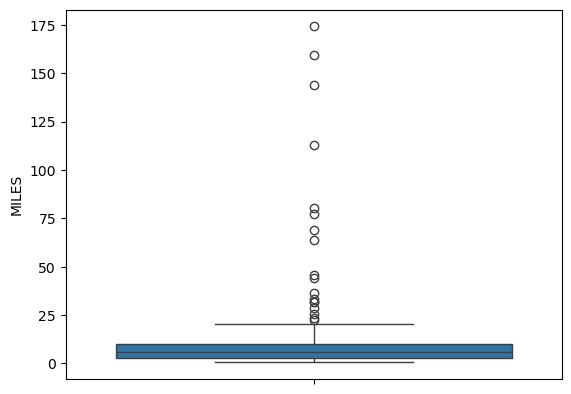

In [70]:
sns.boxplot(df["MILES"])

<Axes: ylabel='MILES'>

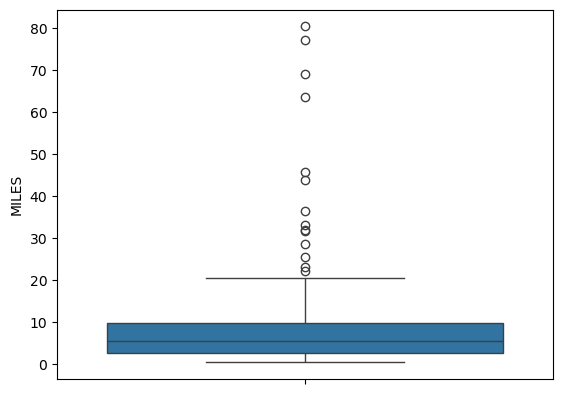

In [74]:
sns.boxplot(df[df["MILES"]<100]["MILES"])

<Axes: ylabel='MILES'>

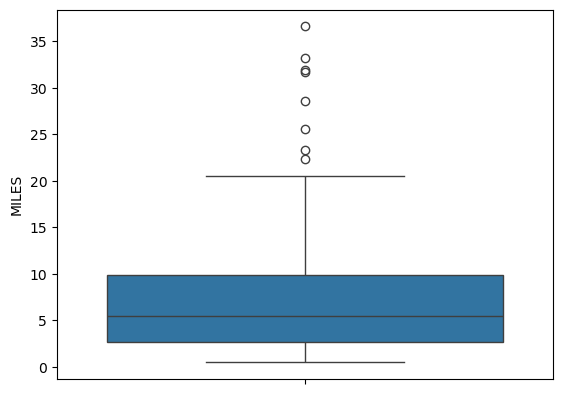

In [75]:
sns.boxplot(df[df["MILES"]<40]["MILES"])

C:\Users\HP\AppData\Local\Temp\ipykernel_11224\58932702.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df["MILES"]<40]["MILES"])


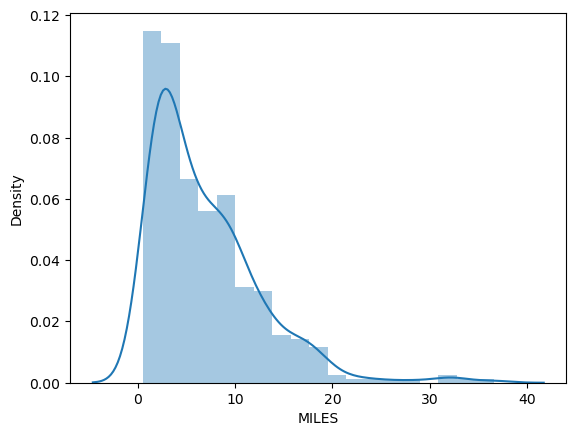

In [79]:
sns.distplot(df[df["MILES"]<40]["MILES"])
plt.show()